In [1]:
%matplotlib inline
import pandas as pd
import numpy as np

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Regression metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Classification metrics
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_palette('muted')

print("✅ All libraries imported!")

✅ All libraries imported!


In [2]:
data = pd.read_parquet("../../data/processed/taxi_engineered.parquet")
print(f"📂 Full dataset: {data.shape[0]:,} trips × {data.shape[1]} columns")

📂 Full dataset: 2,451,103 trips × 45 columns


In [3]:
SAMPLE_SIZE = 500_000
data = data.sample(n=SAMPLE_SIZE, random_state=42)
print(f"✅ Sampled: {data.shape[0]:,} trips")

✅ Sampled: 500,000 trips


In [4]:
# Targets
y_duration = data["trip_duration_min"]
y_congestion = data["has_congestion_fee"]


In [5]:
# Drop leaky / post-trip / irrelevant
drop_cols = [
    "trip_duration_min", "has_congestion_fee", "tpep_pickup_datetime",
    "fare_amount", "extra", "mta_tax", "tip_amount",
    "tolls_amount", "improvement_surcharge", "total_amount",
    "Airport_fee", "congestion_surcharge", "cbd_congestion_fee",
    "avg_speed_mph", "tip_to_total_ratio", "is_extreme_fare",
    "cbd_fee_ratio", "total_surcharges", "surcharges_ratio", "base_fare_ratio",
    "store_and_fwd_encoded", "VendorID", "payment_type", "payment_name",
]
existing_drops = [c for c in drop_cols if c in data.columns]
X = data.drop(columns=existing_drops)

In [6]:
# Encode categoricals
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_cols:
    if X[col].dtype.name == 'category':
        X[col] = X[col].astype(str)
    X[col] = X[col].fillna("Unknown")
    X[col] = LabelEncoder().fit_transform(X[col])

feature_names = X.columns.tolist()

# Train/test split — stratified on congestion fee
X_train, X_test, y_dur_train, y_dur_test, y_cong_train, y_cong_test = train_test_split(
    X, y_duration, y_congestion,
    test_size=0.2, random_state=42, stratify=y_congestion
)

In [7]:
# Scaled versions for Linear/Logistic Regression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
print(f"✅ Data ready — Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"✅ Features: {len(feature_names)}")

✅ Data ready — Train: 400,000 | Test: 100,000
✅ Features: 21


In [9]:
# ## 3. Train All Models

# %%
print("="*60)
print("TRAINING ALL MODELS")
print("="*60)

# --- REGRESSION MODELS ---
print("\n⏳ Training Linear Regression...")
lr_reg = LinearRegression()
lr_reg.fit(X_train_scaled, y_dur_train)
print("   ✅ Done")

print("⏳ Training Random Forest Regressor...")
rf_reg = RandomForestRegressor(
    n_estimators=100, max_depth=30, min_samples_leaf=5,
    random_state=42, n_jobs=-1
)
rf_reg.fit(X_train, y_dur_train)
print("   ✅ Done")

TRAINING ALL MODELS

⏳ Training Linear Regression...
   ✅ Done
⏳ Training Random Forest Regressor...
   ✅ Done


In [10]:
# --- CLASSIFICATION MODELS ---
print("\n⏳ Training Logistic Regression...")
lr_clf = LogisticRegression(max_iter=1000, random_state=42)
lr_clf.fit(X_train_scaled, y_cong_train)
print("   ✅ Done")

print("⏳ Training Random Forest Classifier...")
rf_clf = RandomForestClassifier(
    n_estimators=100, max_depth=30, min_samples_leaf=5,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_clf.fit(X_train, y_cong_train)
print("   ✅ Done")

print("\n✅ All 4 models trained!")


⏳ Training Logistic Regression...
   ✅ Done
⏳ Training Random Forest Classifier...
   ✅ Done

✅ All 4 models trained!


In [11]:
# ## 4. Generate All Predictions

# %%
# Regression predictions
lr_dur_pred_train = lr_reg.predict(X_train_scaled)
lr_dur_pred_test = lr_reg.predict(X_test_scaled)

rf_dur_pred_train = rf_reg.predict(X_train)
rf_dur_pred_test = rf_reg.predict(X_test)

In [12]:
# Classification predictions
lr_cong_pred = lr_clf.predict(X_test_scaled)
lr_cong_proba = lr_clf.predict_proba(X_test_scaled)[:, 1]
lr_cong_pred_train = lr_clf.predict(X_train_scaled)

rf_cong_pred = rf_clf.predict(X_test)
rf_cong_proba = rf_clf.predict_proba(X_test)[:, 1]
rf_cong_pred_train = rf_clf.predict(X_train)

In [13]:
# Naive baselines
naive_dur_rmse = np.sqrt(mean_squared_error(y_dur_test, np.full_like(y_dur_test, y_dur_train.mean())))
naive_cong_accuracy = y_cong_test.value_counts(normalize=True).max()

print("✅ All predictions generated!")

✅ All predictions generated!


In [14]:
# # PART A: Regression Evaluation — Trip Duration
# 
# Comparing Linear Regression vs Random Forest on RMSE, MAE, and R².

# ## 5. Regression Metrics Comparison

print("="*70)
print("REGRESSION EVALUATION: Linear Regression vs Random Forest")
print("="*70)

REGRESSION EVALUATION: Linear Regression vs Random Forest


In [15]:
# Linear Regression metrics
lr_train_rmse = np.sqrt(mean_squared_error(y_dur_train, lr_dur_pred_train))
lr_train_mae = mean_absolute_error(y_dur_train, lr_dur_pred_train)
lr_train_r2 = r2_score(y_dur_train, lr_dur_pred_train)
lr_test_rmse = np.sqrt(mean_squared_error(y_dur_test, lr_dur_pred_test))
lr_test_mae = mean_absolute_error(y_dur_test, lr_dur_pred_test)
lr_test_r2 = r2_score(y_dur_test, lr_dur_pred_test)

In [16]:
# Random Forest metrics
rf_train_rmse = np.sqrt(mean_squared_error(y_dur_train, rf_dur_pred_train))
rf_train_mae = mean_absolute_error(y_dur_train, rf_dur_pred_train)
rf_train_r2 = r2_score(y_dur_train, rf_dur_pred_train)
rf_test_rmse = np.sqrt(mean_squared_error(y_dur_test, rf_dur_pred_test))
rf_test_mae = mean_absolute_error(y_dur_test, rf_dur_pred_test)
rf_test_r2 = r2_score(y_dur_test, rf_dur_pred_test)

In [17]:
print(f"\n{'Model':<25} {'Train RMSE':>12} {'Test RMSE':>12} {'Train MAE':>12} {'Test MAE':>12} {'Train R²':>10} {'Test R²':>10}")
print("─" * 93)
print(f"{'Naive (predict mean)':<25} {'—':>12} {naive_dur_rmse:>12.2f} {'—':>12} {'—':>12} {'—':>10} {'—':>10}")
print(f"{'Linear Regression':<25} {lr_train_rmse:>12.2f} {lr_test_rmse:>12.2f} {lr_train_mae:>12.2f} {lr_test_mae:>12.2f} {lr_train_r2:>10.4f} {lr_test_r2:>10.4f}")
print(f"{'Random Forest':<25} {rf_train_rmse:>12.2f} {rf_test_rmse:>12.2f} {rf_train_mae:>12.2f} {rf_test_mae:>12.2f} {rf_train_r2:>10.4f} {rf_test_r2:>10.4f}")


Model                       Train RMSE    Test RMSE    Train MAE     Test MAE   Train R²    Test R²
─────────────────────────────────────────────────────────────────────────────────────────────
Naive (predict mean)                 —        10.59            —            —          —          —
Linear Regression                 5.40         5.32         3.74         3.72     0.7450     0.7477
Random Forest                     3.10         3.99         1.96         2.61     0.9158     0.8579


In [18]:
# Improvements
rmse_improvement = ((lr_test_rmse - rf_test_rmse) / lr_test_rmse) * 100
mae_improvement = ((lr_test_mae - rf_test_mae) / lr_test_mae) * 100
r2_improvement = ((rf_test_r2 - lr_test_r2) / lr_test_r2) * 100

In [19]:
print(f"\n📊 RF IMPROVEMENT OVER LINEAR REGRESSION:")
print(f"   RMSE: {rmse_improvement:+.1f}% {'(better)' if rmse_improvement > 0 else '(worse)'}")
print(f"   MAE:  {mae_improvement:+.1f}% {'(better)' if mae_improvement > 0 else '(worse)'}")
print(f"   R²:   {r2_improvement:+.1f}% {'(better)' if r2_improvement > 0 else '(worse)'}")

print(f"\n📊 OVERFITTING COMPARISON:")
print(f"   Linear Regression: Train-Test RMSE gap = {abs(lr_train_rmse - lr_test_rmse):.2f} min")
print(f"   Random Forest:     Train-Test RMSE gap = {abs(rf_train_rmse - rf_test_rmse):.2f} min")

print(f"\n📊 STAKEHOLDER GOAL: RMSE < 10 minutes")
print(f"   Linear Regression: {'✅ ACHIEVED' if lr_test_rmse < 10 else '❌ NOT YET'} (RMSE = {lr_test_rmse:.2f})")
print(f"   Random Forest:     {'✅ ACHIEVED' if rf_test_rmse < 10 else '❌ NOT YET'} (RMSE = {rf_test_rmse:.2f})")


📊 RF IMPROVEMENT OVER LINEAR REGRESSION:
   RMSE: +25.0% (better)
   MAE:  +29.9% (better)
   R²:   +14.7% (better)

📊 OVERFITTING COMPARISON:
   Linear Regression: Train-Test RMSE gap = 0.08 min
   Random Forest:     Train-Test RMSE gap = 0.89 min

📊 STAKEHOLDER GOAL: RMSE < 10 minutes
   Linear Regression: ✅ ACHIEVED (RMSE = 5.32)
   Random Forest:     ✅ ACHIEVED (RMSE = 3.99)


In [ ]:
# ## 6. Regression Diagnostic Plots — Side by Side

# %%
n_plot = min(10000, len(y_dur_test))
idx = np.random.RandomState(42).choice(len(y_dur_test), size=n_plot, replace=False)

plt.close('all')
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Regression Evaluation: Linear Regression vs Random Forest', 
             fontsize=16, fontweight='bold', y=1.01)



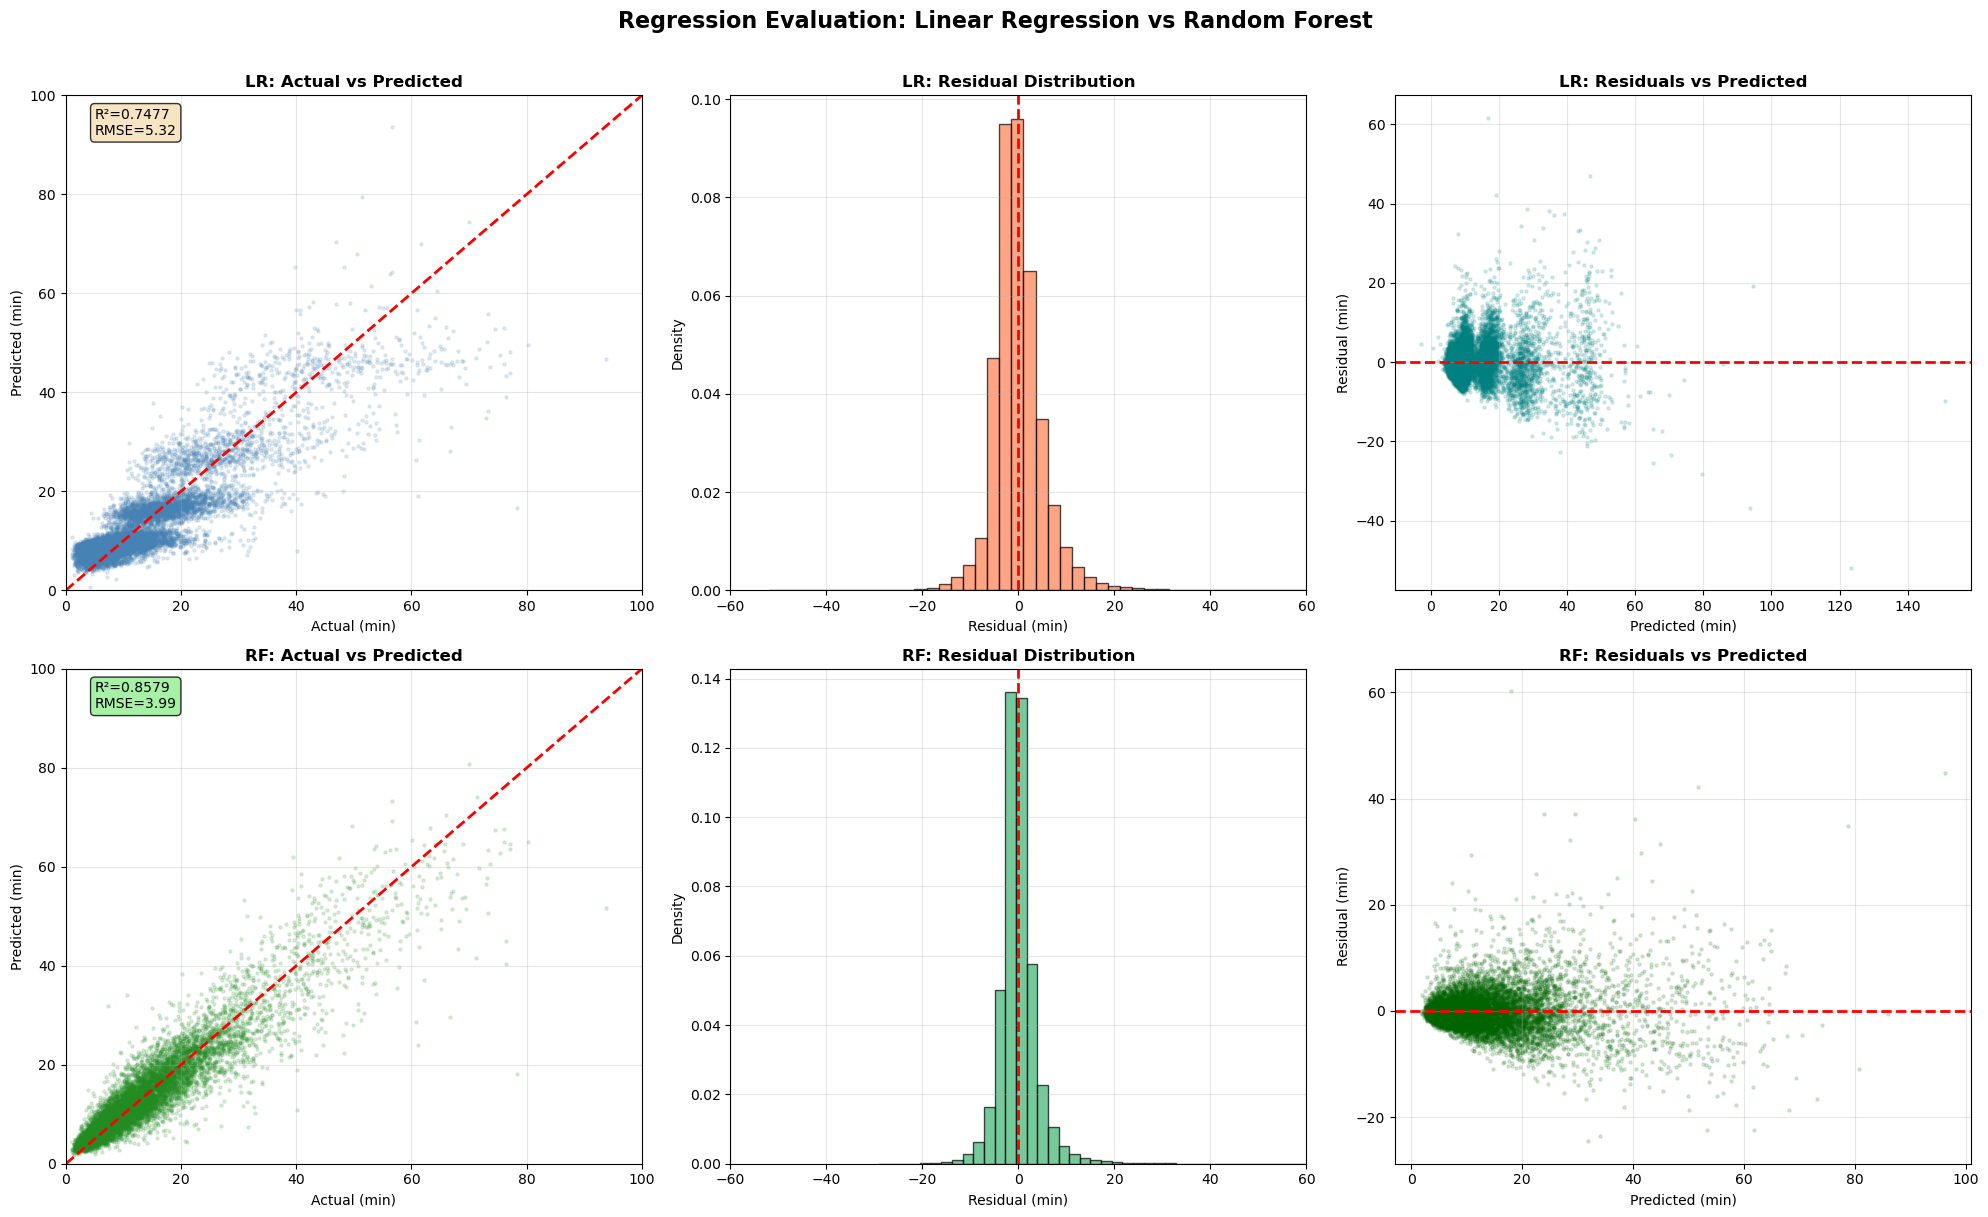

✅ Regression diagnostic plots generated!


In [33]:
# ## 6. Regression Diagnostic Plots — Side by Side

# %%
n_plot = min(10000, len(y_dur_test))
idx = np.random.RandomState(42).choice(len(y_dur_test), size=n_plot, replace=False)

plt.close('all')
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Regression Evaluation: Linear Regression vs Random Forest', 
             fontsize=16, fontweight='bold', y=1.01)


# ── ROW 1: LINEAR REGRESSION ──
lr_residuals = y_dur_test - lr_dur_pred_test

axes[0, 0].scatter(np.array(y_dur_test)[idx], lr_dur_pred_test[idx], alpha=0.15, s=5, color='steelblue')
axes[0, 0].plot([0, 100], [0, 100], 'r--', linewidth=2)
axes[0, 0].set_xlabel('Actual (min)'); axes[0, 0].set_ylabel('Predicted (min)')
axes[0, 0].set_title('LR: Actual vs Predicted', fontweight='bold')
axes[0, 0].set_xlim(0, 100); axes[0, 0].set_ylim(0, 100); axes[0, 0].grid(alpha=0.3)
axes[0, 0].text(0.05, 0.92, f'R²={lr_test_r2:.4f}\nRMSE={lr_test_rmse:.2f}', 
                transform=axes[0, 0].transAxes, fontsize=10,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

axes[0, 1].hist(lr_residuals, bins=80, color='coral', edgecolor='black', alpha=0.7, density=True)
axes[0, 1].axvline(0, color='red', linewidth=2, linestyle='--')
axes[0, 1].set_xlabel('Residual (min)'); axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title('LR: Residual Distribution', fontweight='bold')
axes[0, 1].set_xlim(-60, 60); axes[0, 1].grid(alpha=0.3)

axes[0, 2].scatter(lr_dur_pred_test[idx], np.array(lr_residuals)[idx], alpha=0.15, s=5, color='teal')
axes[0, 2].axhline(0, color='red', linewidth=2, linestyle='--')
axes[0, 2].set_xlabel('Predicted (min)'); axes[0, 2].set_ylabel('Residual (min)')
axes[0, 2].set_title('LR: Residuals vs Predicted', fontweight='bold')
axes[0, 2].grid(alpha=0.3)

# ── ROW 2: RANDOM FOREST ──
rf_residuals = y_dur_test - rf_dur_pred_test

axes[1, 0].scatter(np.array(y_dur_test)[idx], rf_dur_pred_test[idx], alpha=0.15, s=5, color='forestgreen')
axes[1, 0].plot([0, 100], [0, 100], 'r--', linewidth=2)
axes[1, 0].set_xlabel('Actual (min)'); axes[1, 0].set_ylabel('Predicted (min)')
axes[1, 0].set_title('RF: Actual vs Predicted', fontweight='bold')
axes[1, 0].set_xlim(0, 100); axes[1, 0].set_ylim(0, 100); axes[1, 0].grid(alpha=0.3)
axes[1, 0].text(0.05, 0.92, f'R²={rf_test_r2:.4f}\nRMSE={rf_test_rmse:.2f}', 
                transform=axes[1, 0].transAxes, fontsize=10,
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

axes[1, 1].hist(rf_residuals, bins=80, color='mediumseagreen', edgecolor='black', alpha=0.7, density=True)
axes[1, 1].axvline(0, color='red', linewidth=2, linestyle='--')
axes[1, 1].set_xlabel('Residual (min)'); axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('RF: Residual Distribution', fontweight='bold')
axes[1, 1].set_xlim(-60, 60); axes[1, 1].grid(alpha=0.3)

axes[1, 2].scatter(rf_dur_pred_test[idx], np.array(rf_residuals)[idx], alpha=0.15, s=5, color='darkgreen')
axes[1, 2].axhline(0, color='red', linewidth=2, linestyle='--')
axes[1, 2].set_xlabel('Predicted (min)'); axes[1, 2].set_ylabel('Residual (min)')
axes[1, 2].set_title('RF: Residuals vs Predicted', fontweight='bold')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("✅ Regression diagnostic plots generated!")




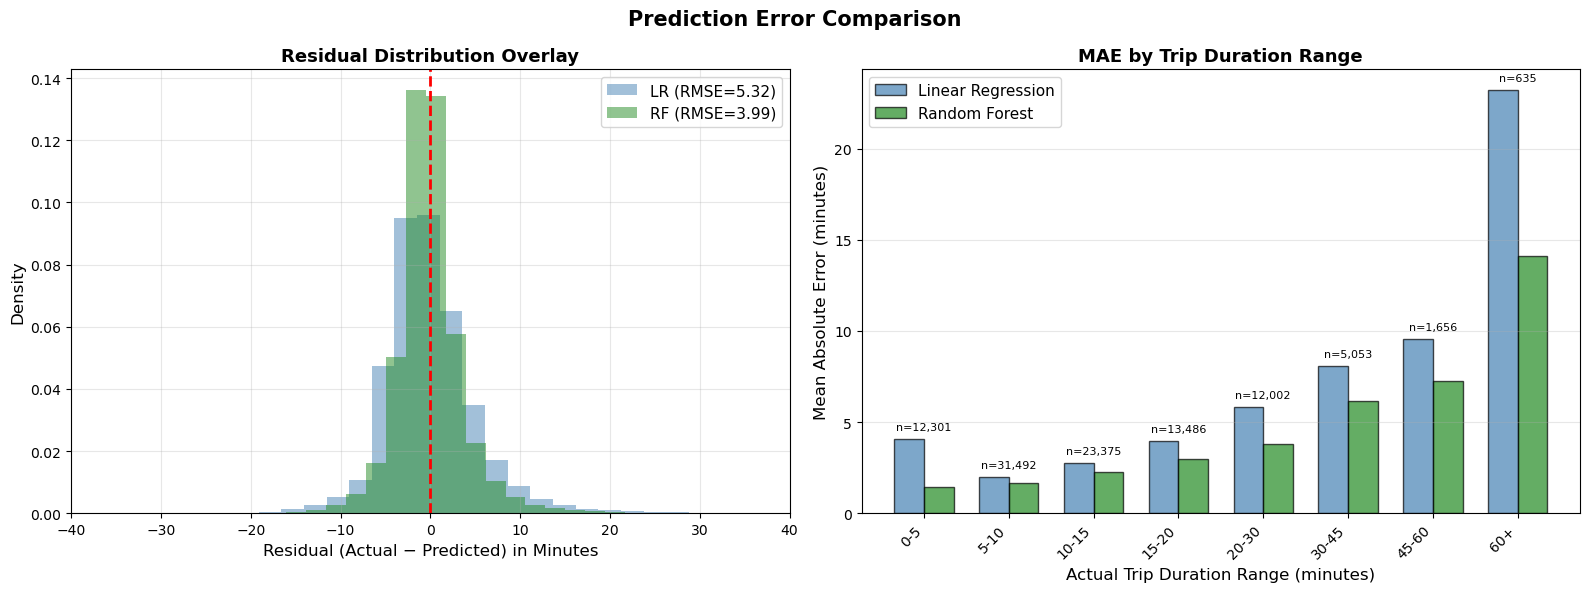

✅ Error comparison plots generated!


In [34]:
# ## 7. Regression — Error Distribution Comparison

# %%
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Prediction Error Comparison', fontsize=15, fontweight='bold', y=0.98)

# Plot 1: Overlaid residual distributions
axes[0].hist(lr_residuals, bins=80, alpha=0.5, color='steelblue', label=f'LR (RMSE={lr_test_rmse:.2f})', density=True)
axes[0].hist(rf_residuals, bins=80, alpha=0.5, color='forestgreen', label=f'RF (RMSE={rf_test_rmse:.2f})', density=True)
axes[0].axvline(0, color='red', linewidth=2, linestyle='--')
axes[0].set_xlabel('Residual (Actual − Predicted) in Minutes', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Residual Distribution Overlay', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].set_xlim(-40, 40)
axes[0].grid(alpha=0.3)

# Plot 2: MAE by duration range
bins = [0, 5, 10, 15, 20, 30, 45, 60, 180]
bin_labels = ['0-5', '5-10', '10-15', '15-20', '20-30', '30-45', '45-60', '60+']
y_test_binned = pd.cut(y_dur_test, bins=bins, labels=bin_labels)

error_df = pd.DataFrame({
    'bin': y_test_binned,
    'lr_error': np.abs(np.array(y_dur_test) - lr_dur_pred_test),
    'rf_error': np.abs(np.array(y_dur_test) - rf_dur_pred_test)
})
mae_by_bin = error_df.groupby('bin', observed=True).agg(
    lr_mae=('lr_error', 'mean'),
    rf_mae=('rf_error', 'mean'),
    count=('lr_error', 'count')
).reset_index()

x_pos = np.arange(len(mae_by_bin))
width = 0.35

axes[1].bar(x_pos - width/2, mae_by_bin['lr_mae'], width, color='steelblue', alpha=0.7, label='Linear Regression', edgecolor='black')
axes[1].bar(x_pos + width/2, mae_by_bin['rf_mae'], width, color='forestgreen', alpha=0.7, label='Random Forest', edgecolor='black')
axes[1].set_xlabel('Actual Trip Duration Range (minutes)', fontsize=12)
axes[1].set_ylabel('Mean Absolute Error (minutes)', fontsize=12)
axes[1].set_title('MAE by Trip Duration Range', fontweight='bold', fontsize=13)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(mae_by_bin['bin'], rotation=45, ha='right')
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

# Add count labels
for i, count in enumerate(mae_by_bin['count']):
    axes[1].text(i, max(mae_by_bin['lr_mae'].iloc[i], mae_by_bin['rf_mae'].iloc[i]) + 0.5,
                 f'n={count:,}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()
print("✅ Error comparison plots generated!")


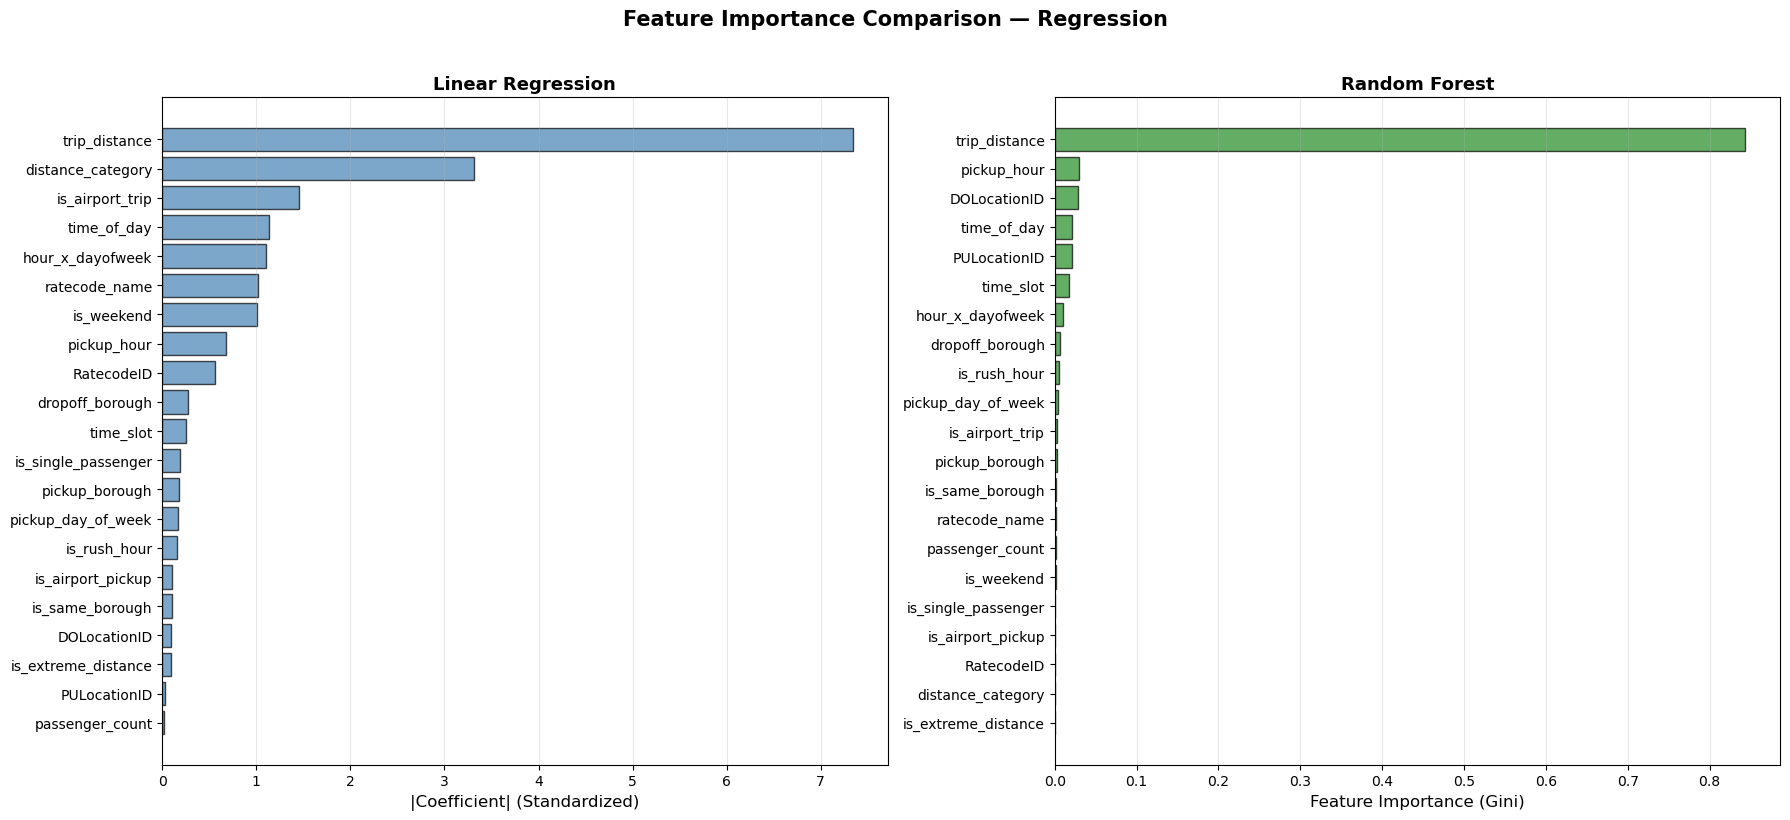

✅ Feature importance comparison generated!


In [25]:
# ## 8. Regression — Feature Importance Comparison

# %%
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Feature Importance Comparison — Regression', fontsize=15, fontweight='bold', y=1.02)

# LR coefficients (absolute)
lr_coef = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(lr_reg.coef_)
}).sort_values('Importance', ascending=True)

axes[0].barh(lr_coef['Feature'], lr_coef['Importance'], color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('|Coefficient| (Standardized)', fontsize=12)
axes[0].set_title('Linear Regression', fontweight='bold', fontsize=13)
axes[0].grid(axis='x', alpha=0.3)

# RF feature importance
rf_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_reg.feature_importances_
}).sort_values('Importance', ascending=True)

axes[1].barh(rf_imp['Feature'], rf_imp['Importance'], color='forestgreen', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Feature Importance (Gini)', fontsize=12)
axes[1].set_title('Random Forest', fontweight='bold', fontsize=13)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()
print("✅ Feature importance comparison generated!")


In [26]:
# # PART B: Classification Evaluation — Congestion Fee
# 
# Comparing Logistic Regression vs Random Forest on Accuracy, AUC, F1, 
# Precision, and Recall.

# %% [markdown]
# ---
# ## 9. Classification Metrics Comparison

# %%
print("="*70)
print("CLASSIFICATION EVALUATION: Logistic Regression vs Random Forest")
print("="*70)

# Logistic Regression metrics
lr_clf_accuracy = accuracy_score(y_cong_test, lr_cong_pred)
lr_clf_auc = roc_auc_score(y_cong_test, lr_cong_proba)
lr_clf_f1 = f1_score(y_cong_test, lr_cong_pred)
lr_clf_precision = precision_score(y_cong_test, lr_cong_pred)
lr_clf_recall = recall_score(y_cong_test, lr_cong_pred)
lr_train_acc = accuracy_score(y_cong_train, lr_cong_pred_train)

# Random Forest metrics
rf_clf_accuracy = accuracy_score(y_cong_test, rf_cong_pred)
rf_clf_auc = roc_auc_score(y_cong_test, rf_cong_proba)
rf_clf_f1 = f1_score(y_cong_test, rf_cong_pred)
rf_clf_precision = precision_score(y_cong_test, rf_cong_pred)
rf_clf_recall = recall_score(y_cong_test, rf_cong_pred)
rf_train_acc = accuracy_score(y_cong_train, rf_cong_pred_train)

print(f"\n{'Model':<25} {'Accuracy':>10} {'AUC':>10} {'F1':>10} {'Precision':>10} {'Recall':>10}")
print("─" * 77)
print(f"{'Naive (predict YES)':<25} {naive_cong_accuracy:>10.4f} {'—':>10} {'—':>10} {'—':>10} {'—':>10}")
print(f"{'Logistic Regression':<25} {lr_clf_accuracy:>10.4f} {lr_clf_auc:>10.4f} {lr_clf_f1:>10.4f} {lr_clf_precision:>10.4f} {lr_clf_recall:>10.4f}")
print(f"{'Random Forest':<25} {rf_clf_accuracy:>10.4f} {rf_clf_auc:>10.4f} {rf_clf_f1:>10.4f} {rf_clf_precision:>10.4f} {rf_clf_recall:>10.4f}")

print(f"\n📊 RF IMPROVEMENT OVER LOGISTIC REGRESSION:")
auc_imp = ((rf_clf_auc - lr_clf_auc) / lr_clf_auc) * 100
f1_imp = ((rf_clf_f1 - lr_clf_f1) / lr_clf_f1) * 100
print(f"   AUC: {auc_imp:+.1f}%")
print(f"   F1:  {f1_imp:+.1f}%")

print(f"\n📊 OVERFITTING COMPARISON:")
print(f"   Logistic Regression: Train Acc = {lr_train_acc:.4f}, Test Acc = {lr_clf_accuracy:.4f}, Gap = {abs(lr_train_acc - lr_clf_accuracy):.4f}")
print(f"   Random Forest:       Train Acc = {rf_train_acc:.4f}, Test Acc = {rf_clf_accuracy:.4f}, Gap = {abs(rf_train_acc - rf_clf_accuracy):.4f}")


CLASSIFICATION EVALUATION: Logistic Regression vs Random Forest

Model                       Accuracy        AUC         F1  Precision     Recall
─────────────────────────────────────────────────────────────────────────────
Naive (predict YES)           0.7438          —          —          —          —
Logistic Regression           0.7750     0.7336     0.8661     0.7770     0.9783
Random Forest                 0.9533     0.9794     0.9684     0.9759     0.9609

📊 RF IMPROVEMENT OVER LOGISTIC REGRESSION:
   AUC: +33.5%
   F1:  +11.8%

📊 OVERFITTING COMPARISON:
   Logistic Regression: Train Acc = 0.7742, Test Acc = 0.7750, Gap = 0.0008
   Random Forest:       Train Acc = 0.9637, Test Acc = 0.9533, Gap = 0.0104


In [27]:
# Classification Reports
print("\n" + "="*70)
print("LOGISTIC REGRESSION — CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_cong_test, lr_cong_pred, target_names=["No Fee (0)", "Has Fee (1)"]))

print("="*70)
print("RANDOM FOREST — CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_cong_test, rf_cong_pred, target_names=["No Fee (0)", "Has Fee (1)"]))



LOGISTIC REGRESSION — CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Fee (0)       0.75      0.18      0.30     25625
 Has Fee (1)       0.78      0.98      0.87     74375

    accuracy                           0.77    100000
   macro avg       0.76      0.58      0.58    100000
weighted avg       0.77      0.77      0.72    100000

RANDOM FOREST — CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Fee (0)       0.89      0.93      0.91     25625
 Has Fee (1)       0.98      0.96      0.97     74375

    accuracy                           0.95    100000
   macro avg       0.93      0.95      0.94    100000
weighted avg       0.95      0.95      0.95    100000



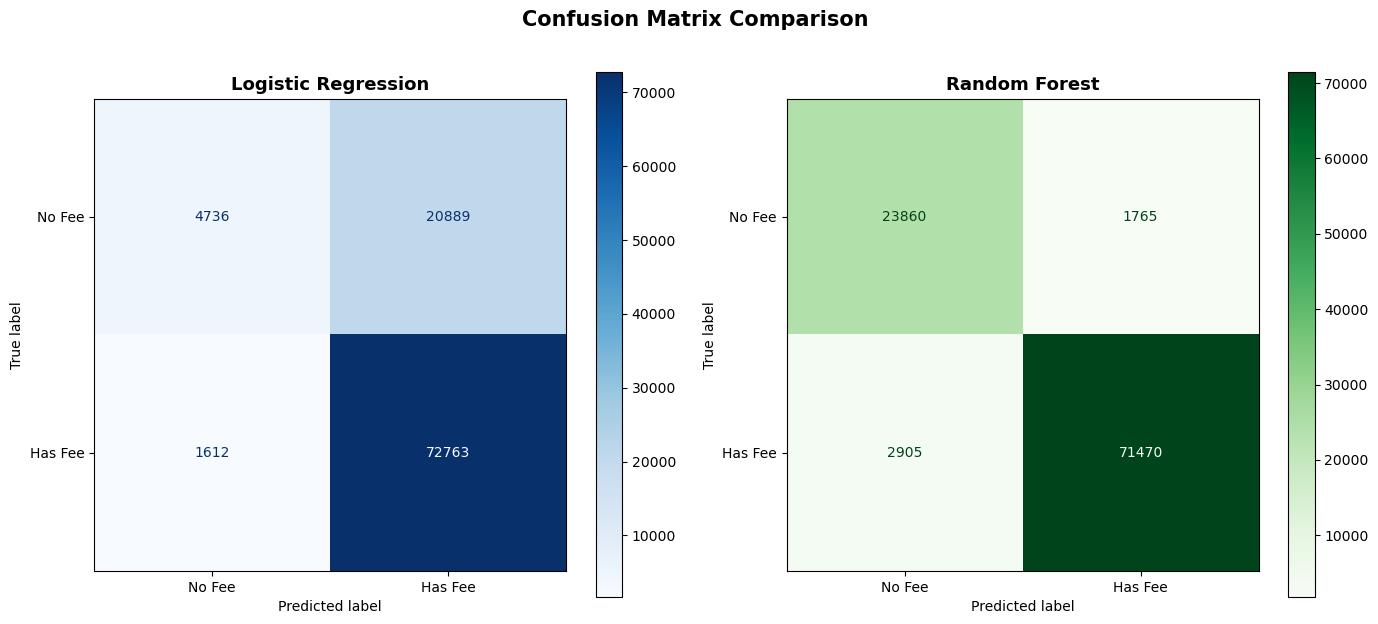

✅ Confusion matrices generated!


In [28]:
# ## 10. Classification — Confusion Matrices Side by Side

# %%
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Confusion Matrix Comparison', fontsize=15, fontweight='bold', y=1.02)

ConfusionMatrixDisplay.from_predictions(
    y_cong_test, lr_cong_pred,
    display_labels=["No Fee", "Has Fee"],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Logistic Regression', fontweight='bold', fontsize=13)

ConfusionMatrixDisplay.from_predictions(
    y_cong_test, rf_cong_pred,
    display_labels=["No Fee", "Has Fee"],
    cmap='Greens', ax=axes[1]
)
axes[1].set_title('Random Forest', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()
print("✅ Confusion matrices generated!")

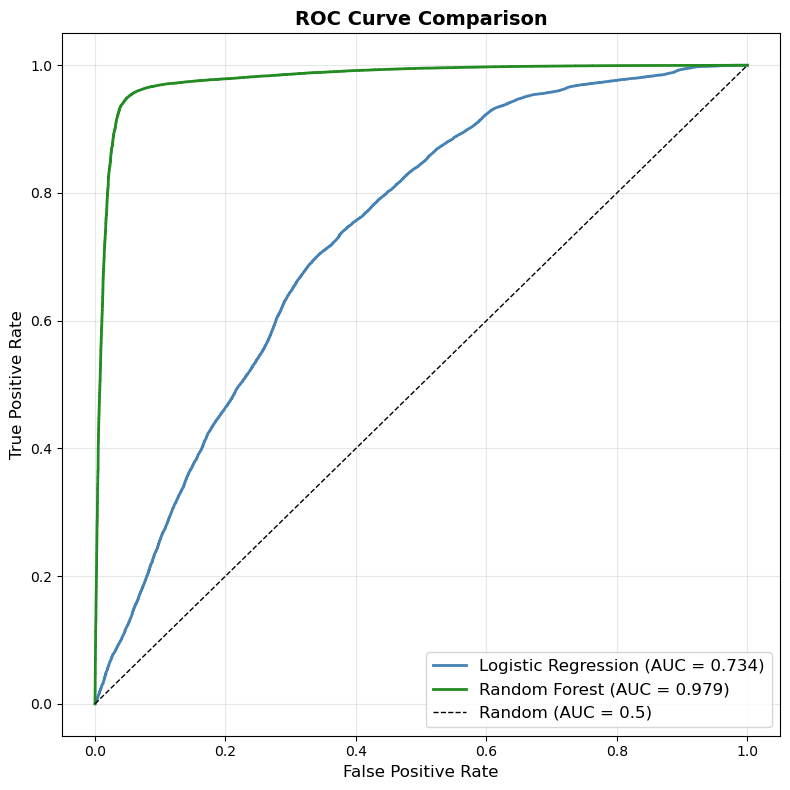

✅ ROC curve comparison generated!


In [29]:
# ## 11. Classification — ROC Curves Comparison

# %%
fig, ax = plt.subplots(figsize=(8, 8))

# Logistic Regression ROC
lr_fpr, lr_tpr, _ = roc_curve(y_cong_test, lr_cong_proba)
ax.plot(lr_fpr, lr_tpr, color='steelblue', linewidth=2, label=f'Logistic Regression (AUC = {lr_clf_auc:.3f})')

# Random Forest ROC
rf_fpr, rf_tpr, _ = roc_curve(y_cong_test, rf_cong_proba)
ax.plot(rf_fpr, rf_tpr, color='forestgreen', linewidth=2, label=f'Random Forest (AUC = {rf_clf_auc:.3f})')

# Random baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=12, loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("✅ ROC curve comparison generated!")

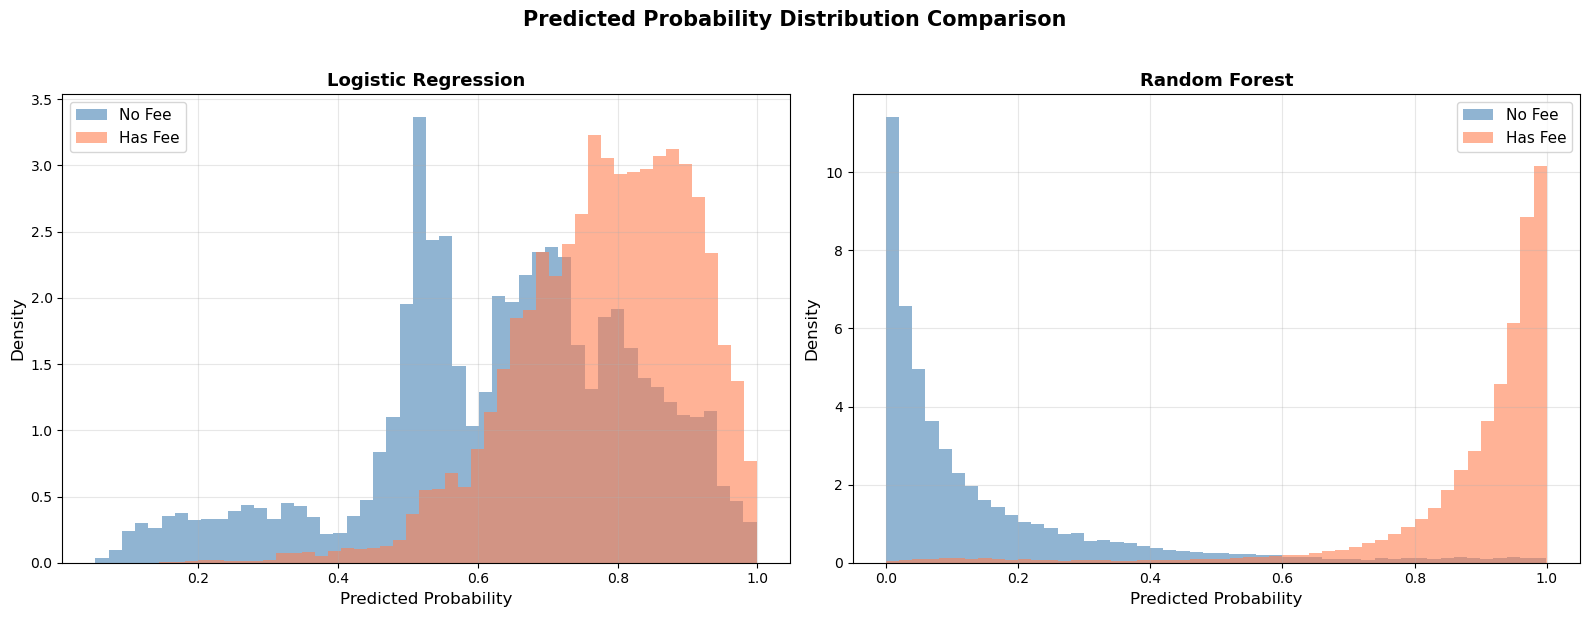

✅ Probability distribution comparison generated!


In [30]:
# ## 12. Classification — Predicted Probability Comparison

# %%
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Predicted Probability Distribution Comparison', fontsize=15, fontweight='bold', y=1.02)

# Logistic Regression
axes[0].hist(lr_cong_proba[y_cong_test == 0], bins=50, alpha=0.6, color='steelblue', label='No Fee', density=True)
axes[0].hist(lr_cong_proba[y_cong_test == 1], bins=50, alpha=0.6, color='coral', label='Has Fee', density=True)
axes[0].set_xlabel('Predicted Probability', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Logistic Regression', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Random Forest
axes[1].hist(rf_cong_proba[y_cong_test == 0], bins=50, alpha=0.6, color='steelblue', label='No Fee', density=True)
axes[1].hist(rf_cong_proba[y_cong_test == 1], bins=50, alpha=0.6, color='coral', label='Has Fee', density=True)
axes[1].set_xlabel('Predicted Probability', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Random Forest', fontweight='bold', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("✅ Probability distribution comparison generated!")


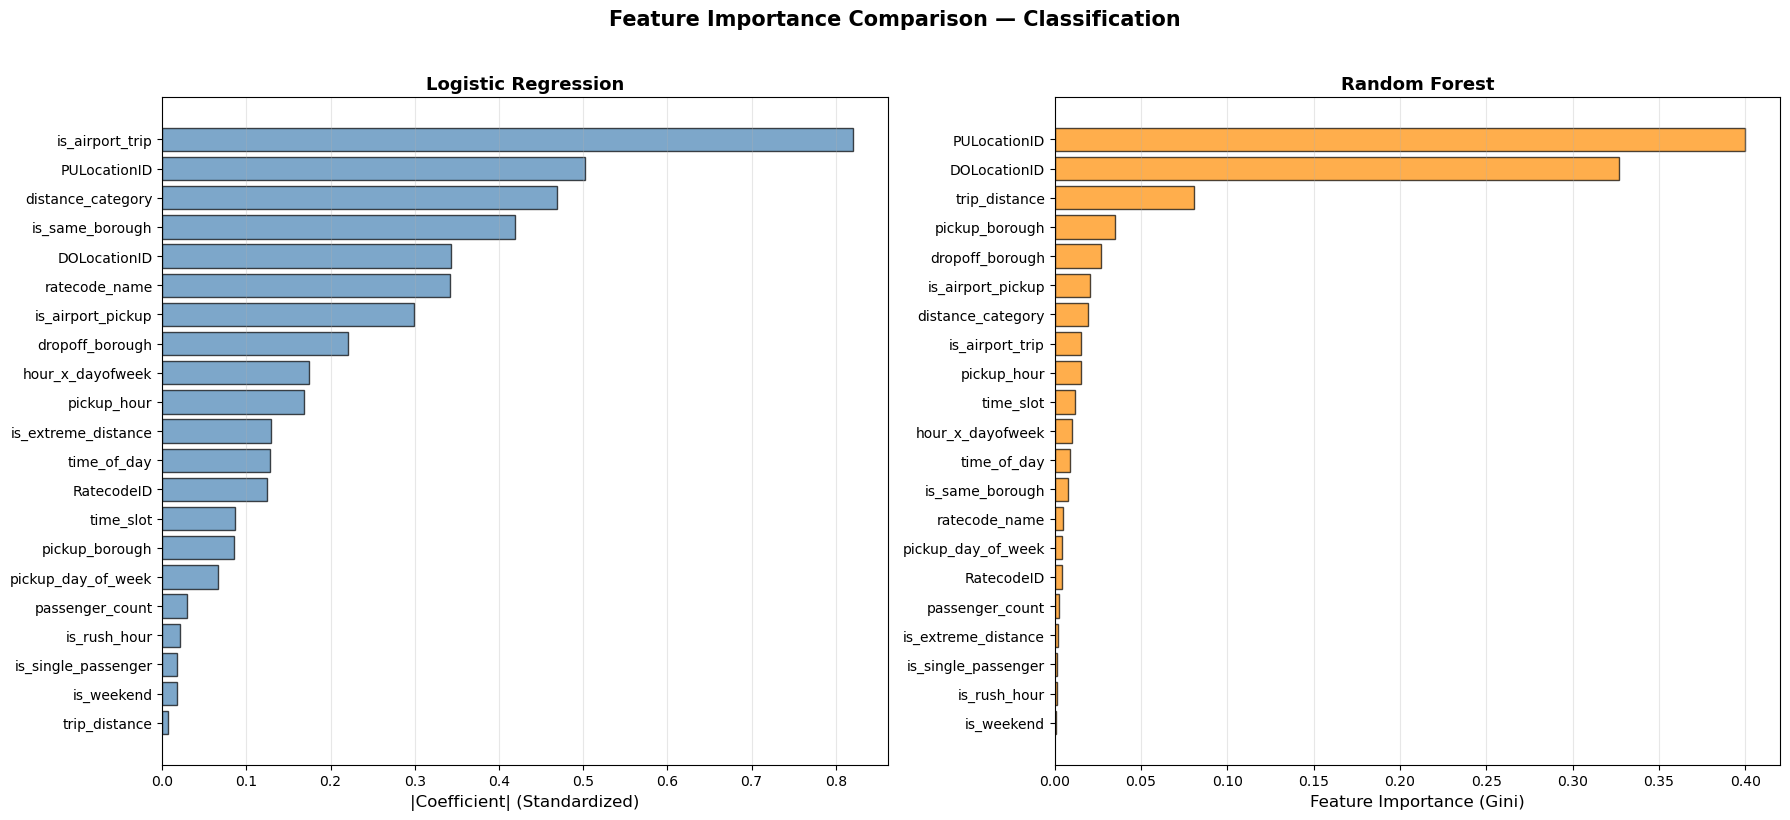

✅ Classification feature importance comparison generated!


In [31]:
# ## 13. Classification — Feature Importance Comparison

# %%
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Feature Importance Comparison — Classification', fontsize=15, fontweight='bold', y=1.02)

# Logistic Regression coefficients (absolute)
lr_clf_coef = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(lr_clf.coef_[0])
}).sort_values('Importance', ascending=True)

axes[0].barh(lr_clf_coef['Feature'], lr_clf_coef['Importance'], color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('|Coefficient| (Standardized)', fontsize=12)
axes[0].set_title('Logistic Regression', fontweight='bold', fontsize=13)
axes[0].grid(axis='x', alpha=0.3)

# RF feature importance
rf_clf_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_clf.feature_importances_
}).sort_values('Importance', ascending=True)

axes[1].barh(rf_clf_imp['Feature'], rf_clf_imp['Importance'], color='darkorange', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Feature Importance (Gini)', fontsize=12)
axes[1].set_title('Random Forest', fontweight='bold', fontsize=13)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()
print("✅ Classification feature importance comparison generated!")


In [32]:
# ## 14. Final Combined Summary

# %%
print("="*70)
print("FINAL EVALUATION SUMMARY — Abhishek's Models")
print("="*70)

print(f"""
{'─'*70}
  REGRESSION: Trip Duration Prediction
{'─'*70}

  {'Model':<25} {'RMSE':>8} {'MAE':>8} {'R²':>8} {'Overfit Gap':>12}
  {'─'*61}
  {'Naive (predict mean)':<25} {naive_dur_rmse:>8.2f} {'—':>8} {'—':>8} {'—':>12}
  {'Linear Regression':<25} {lr_test_rmse:>8.2f} {lr_test_mae:>8.2f} {lr_test_r2:>8.4f} {abs(lr_train_rmse - lr_test_rmse):>11.2f}m
  {'Random Forest':<25} {rf_test_rmse:>8.2f} {rf_test_mae:>8.2f} {rf_test_r2:>8.4f} {abs(rf_train_rmse - rf_test_rmse):>11.2f}m

  RF improvement over LR: RMSE {rmse_improvement:+.1f}% | MAE {mae_improvement:+.1f}% | R² {r2_improvement:+.1f}%
  Stakeholder Goal (RMSE < 10): Both models ✅

{'─'*70}
  CLASSIFICATION: Congestion Fee Prediction
{'─'*70}

  {'Model':<25} {'Accuracy':>10} {'AUC':>8} {'F1':>8} {'Precision':>10} {'Recall':>8}
  {'─'*70}
  {'Naive (predict YES)':<25} {naive_cong_accuracy:>10.4f} {'—':>8} {'—':>8} {'—':>10} {'—':>8}
  {'Logistic Regression':<25} {lr_clf_accuracy:>10.4f} {lr_clf_auc:>8.4f} {lr_clf_f1:>8.4f} {lr_clf_precision:>10.4f} {lr_clf_recall:>8.4f}
  {'Random Forest':<25} {rf_clf_accuracy:>10.4f} {rf_clf_auc:>8.4f} {rf_clf_f1:>8.4f} {rf_clf_precision:>10.4f} {rf_clf_recall:>8.4f}

  RF improvement over LR: AUC {auc_imp:+.1f}% | F1 {f1_imp:+.1f}%

{'─'*70}
  KEY TAKEAWAYS
{'─'*70}
  1. Random Forest significantly outperforms Linear/Logistic baselines on both tasks
  2. RF captures non-linear patterns (location × time interactions) that linear models miss
  3. Overfitting is controlled with max_depth=30 and min_samples_leaf=5
  4. For regression, trip_distance is the dominant predictor in both models
  5. For classification, location features (PULocationID, DOLocationID) drive predictions
     — confirming the stakeholder insight that congestion fee is fundamentally spatial
""")

print("="*70)
print("✅ Abhishek's model evaluation complete!")
print("="*70)

FINAL EVALUATION SUMMARY — Abhishek's Models

──────────────────────────────────────────────────────────────────────
  REGRESSION: Trip Duration Prediction
──────────────────────────────────────────────────────────────────────

  Model                         RMSE      MAE       R²  Overfit Gap
  ─────────────────────────────────────────────────────────────
  Naive (predict mean)         10.59        —        —            —
  Linear Regression             5.32     3.72   0.7477        0.08m
  Random Forest                 3.99     2.61   0.8579        0.89m

  RF improvement over LR: RMSE +25.0% | MAE +29.9% | R² +14.7%
  Stakeholder Goal (RMSE < 10): Both models ✅

──────────────────────────────────────────────────────────────────────
  CLASSIFICATION: Congestion Fee Prediction
──────────────────────────────────────────────────────────────────────

  Model                       Accuracy      AUC       F1  Precision   Recall
  ───────────────────────────────────────────────────────────